## Welcome to the Brain Detective Lab! 🧬

In [22]:
# Here, we are just preparing our working environment, making sure that we have everything we need to start working.
# You don't need to do a thing here :)

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.bottom": False,
    "axes.spines.left": False
})

print("✅ Mission Control is ready!")

✅ Mission Control is ready!


## Loading our dataset, with cells (workers) and their genes (tools)

In [23]:
# Here we load our cerebellum dataset. Let's call it "cerebellum_data" from now on.
# You still don't need to no anything here. :)

cerebellum_data = sc.read_h5ad("processed_descartes_cerebellum.h5ad")

print(f"The dataset is loaded! We have {cerebellum_data.n_obs} cells to investigate.")
print("Each cell has a set of 'tools' (genes) that tells us its job.")

The dataset is loaded! We have 44428 cells to investigate.
Each cell has a set of 'tools' (genes) that tells us its job.


## Visualizing our cells (workers), already grouped into teams

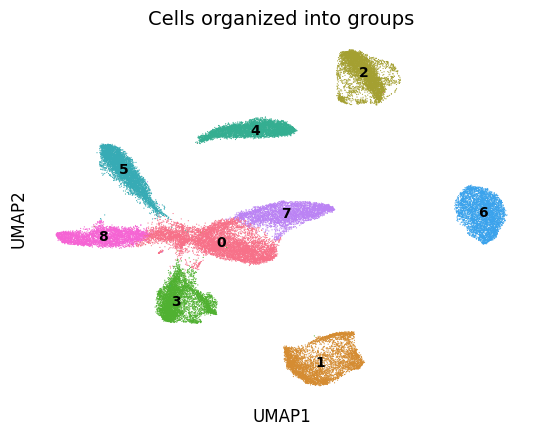

In [25]:
# The following map allows you so see all the cells we have in our dataset.
# For simplicity, the cells are already grouped together if they are part of the same team, that is, if they have the same function.
# We have a total of 9 teams and 9 types of cells. Or job will be to find out what are the names of the cell types of each of these teams.
# Look at the map bellow. Each team as a color and a number.
sc.pl.umap(cerebellum_data, color='leiden', legend_loc='on data', title="Cells organized into groups", palette=sns.color_palette("husl",9))

## Cell 4: The Detective Search (The genes - or ingredients - are glowing) 🔦

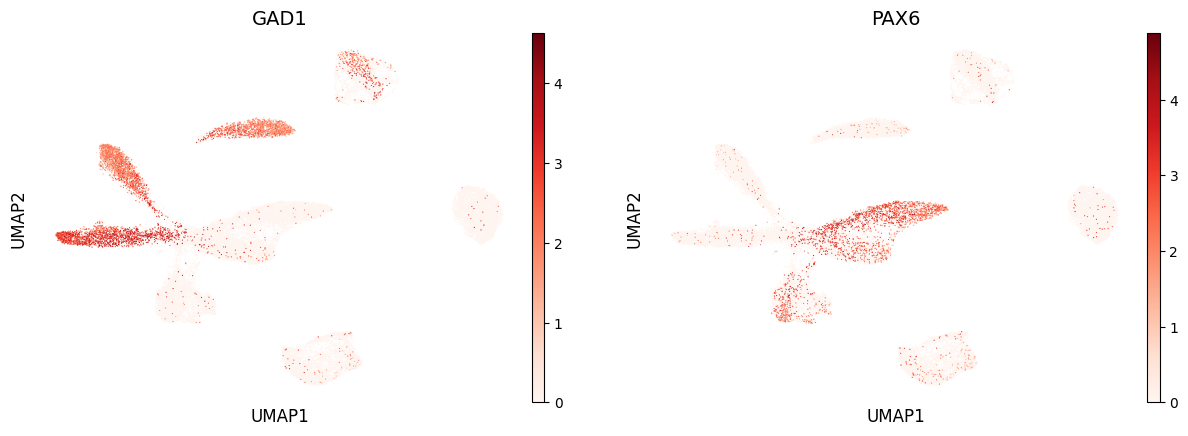

In [ ]:
# You can see which cell have which types of tools in various ways. Here, we have a look at one of these ways.
# You just need to write down the name of the tools you would like to investif=gate and, by pressing play, you will see which cells (workers) need them the most.andIf a cell is colored in red, it means that it uses that tool a lot.
# If it is colored in white, it means that that cell doesn't use that tool at all!
# Here's one example with the tools "GAD1" and "PAX6", but you can have replace their names by others and see what happens.

target_genes = ["GAD1", "PAX6"]

sc.pl.umap(cerebellum_data, color=target_genes, use_raw=True, cmap="Reds")

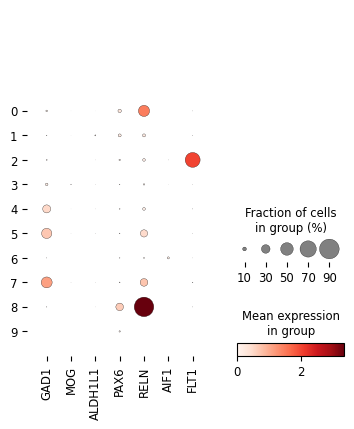

In [ ]:
# Another way of checking which cells need which tools is presented here. In this manner, you can see them already organized by teams. This type of image is called dotplot.
# If a dot is very bigg and dark red, it means that the respective team needs it a lot. If the dot is just slightly red, means that the team needs in an average way. And if the dot is very light colored, or almost white, it means that the team very rarely uses that tool.
# I'm giving you an example with a list of tools, "GAD1", "MOG", "ALDH1L1", "PAX6", "RELN", "AIF1", "FLT1". You can see, for example, that team 8 needs "RELN" a lot, and team 0 uses it a bit. On the other hand, only team 2 uses FLT1 for example.
# Replace the genes (tools) in this list but others of your choice to find the correspondance between teams of workers (cells) and their tools.

target_genes = ["GAD1", "MOG", "ALDH1L1", "PAX6", "RELN", "AIF1", "FLT1"]

sc.pl.dotplot(cerebellum_data, target_genes, groupby='leiden', use_raw=True)

## Giving the teams their real names 🏷️
Instruction: This is the "Challenge" part. Once you have enough evidece that Team 0 is a certain cell type, you should update this list.

In [27]:
# Look at your cards. There you'll find the names of the tools they famously use. 
# By using the previous commands as template, you should find the names of the cells from each of the teams.

# Change the names inside the "quotes" below:
id_to_name = {
    "0": "Cell Type A",
    "1": "Cell Type B",
    "2": "Cell Type C",
    "3": "Cell Type D",
    "4": "Cell Type E",
    "5": "Cell Type F",
    "6": "Cell Type G",
    "7": "Cell Type H",
    "8": "Cell Type I"
}

# The following command adds the tags you created for each team to the dataset, so that you can visualize them in the next step.
cerebellum_data.obs['cell_type'] = cerebellum_data.obs['leiden'].map(id_to_name)

print("Names updated! Ready for the final reveal?")

Names updated! Ready for the final reveal?


## The Final Masterpiece! 🎨

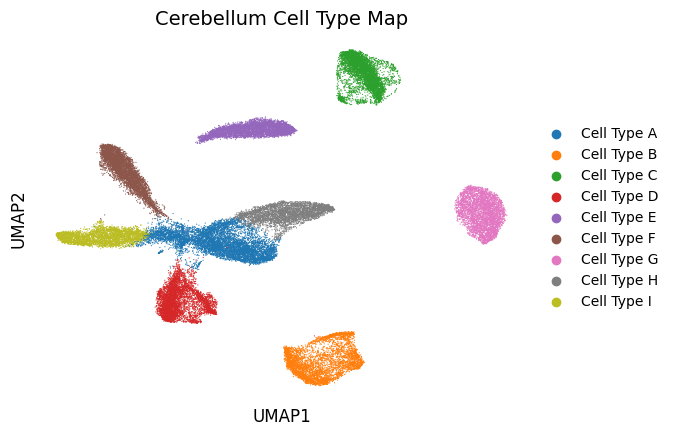

In [28]:
# Let's see how the map looks now that you have given each of the teams their official names!
sc.pl.umap(cerebellum_data, color='cell_type', title="Cerebellum Cell Type Map")

In [ ]:
# Run this cell to save the labelled dataset.

output_file = "final_masterpieace.h5ad"
cerebellum_data.write(output_file)